LOADING RESULTS

✓ Loaded 217 rows from C:\Users\kyma3609\OneDrive - UCB-O365\Recreation_Fire\Code\CulturalES_WildfireRx\outputs\dif_in_dif\did_heterogeneity_results.csv

States: ['CO' 'CA']
Fire types: ['wildfire' 'prescribed']
Stratifications: ['size' 'severity' 'vegetation' 'recreation']

CREATING FIGURE: HETEROGENEOUS EFFECTS

✓ Saved figures to: C:\Users\kyma3609\OneDrive - UCB-O365\Recreation_Fire\Code\CulturalES_WildfireRx\outputs\figures
  • Heterogeneous_Effects.png (600 DPI)


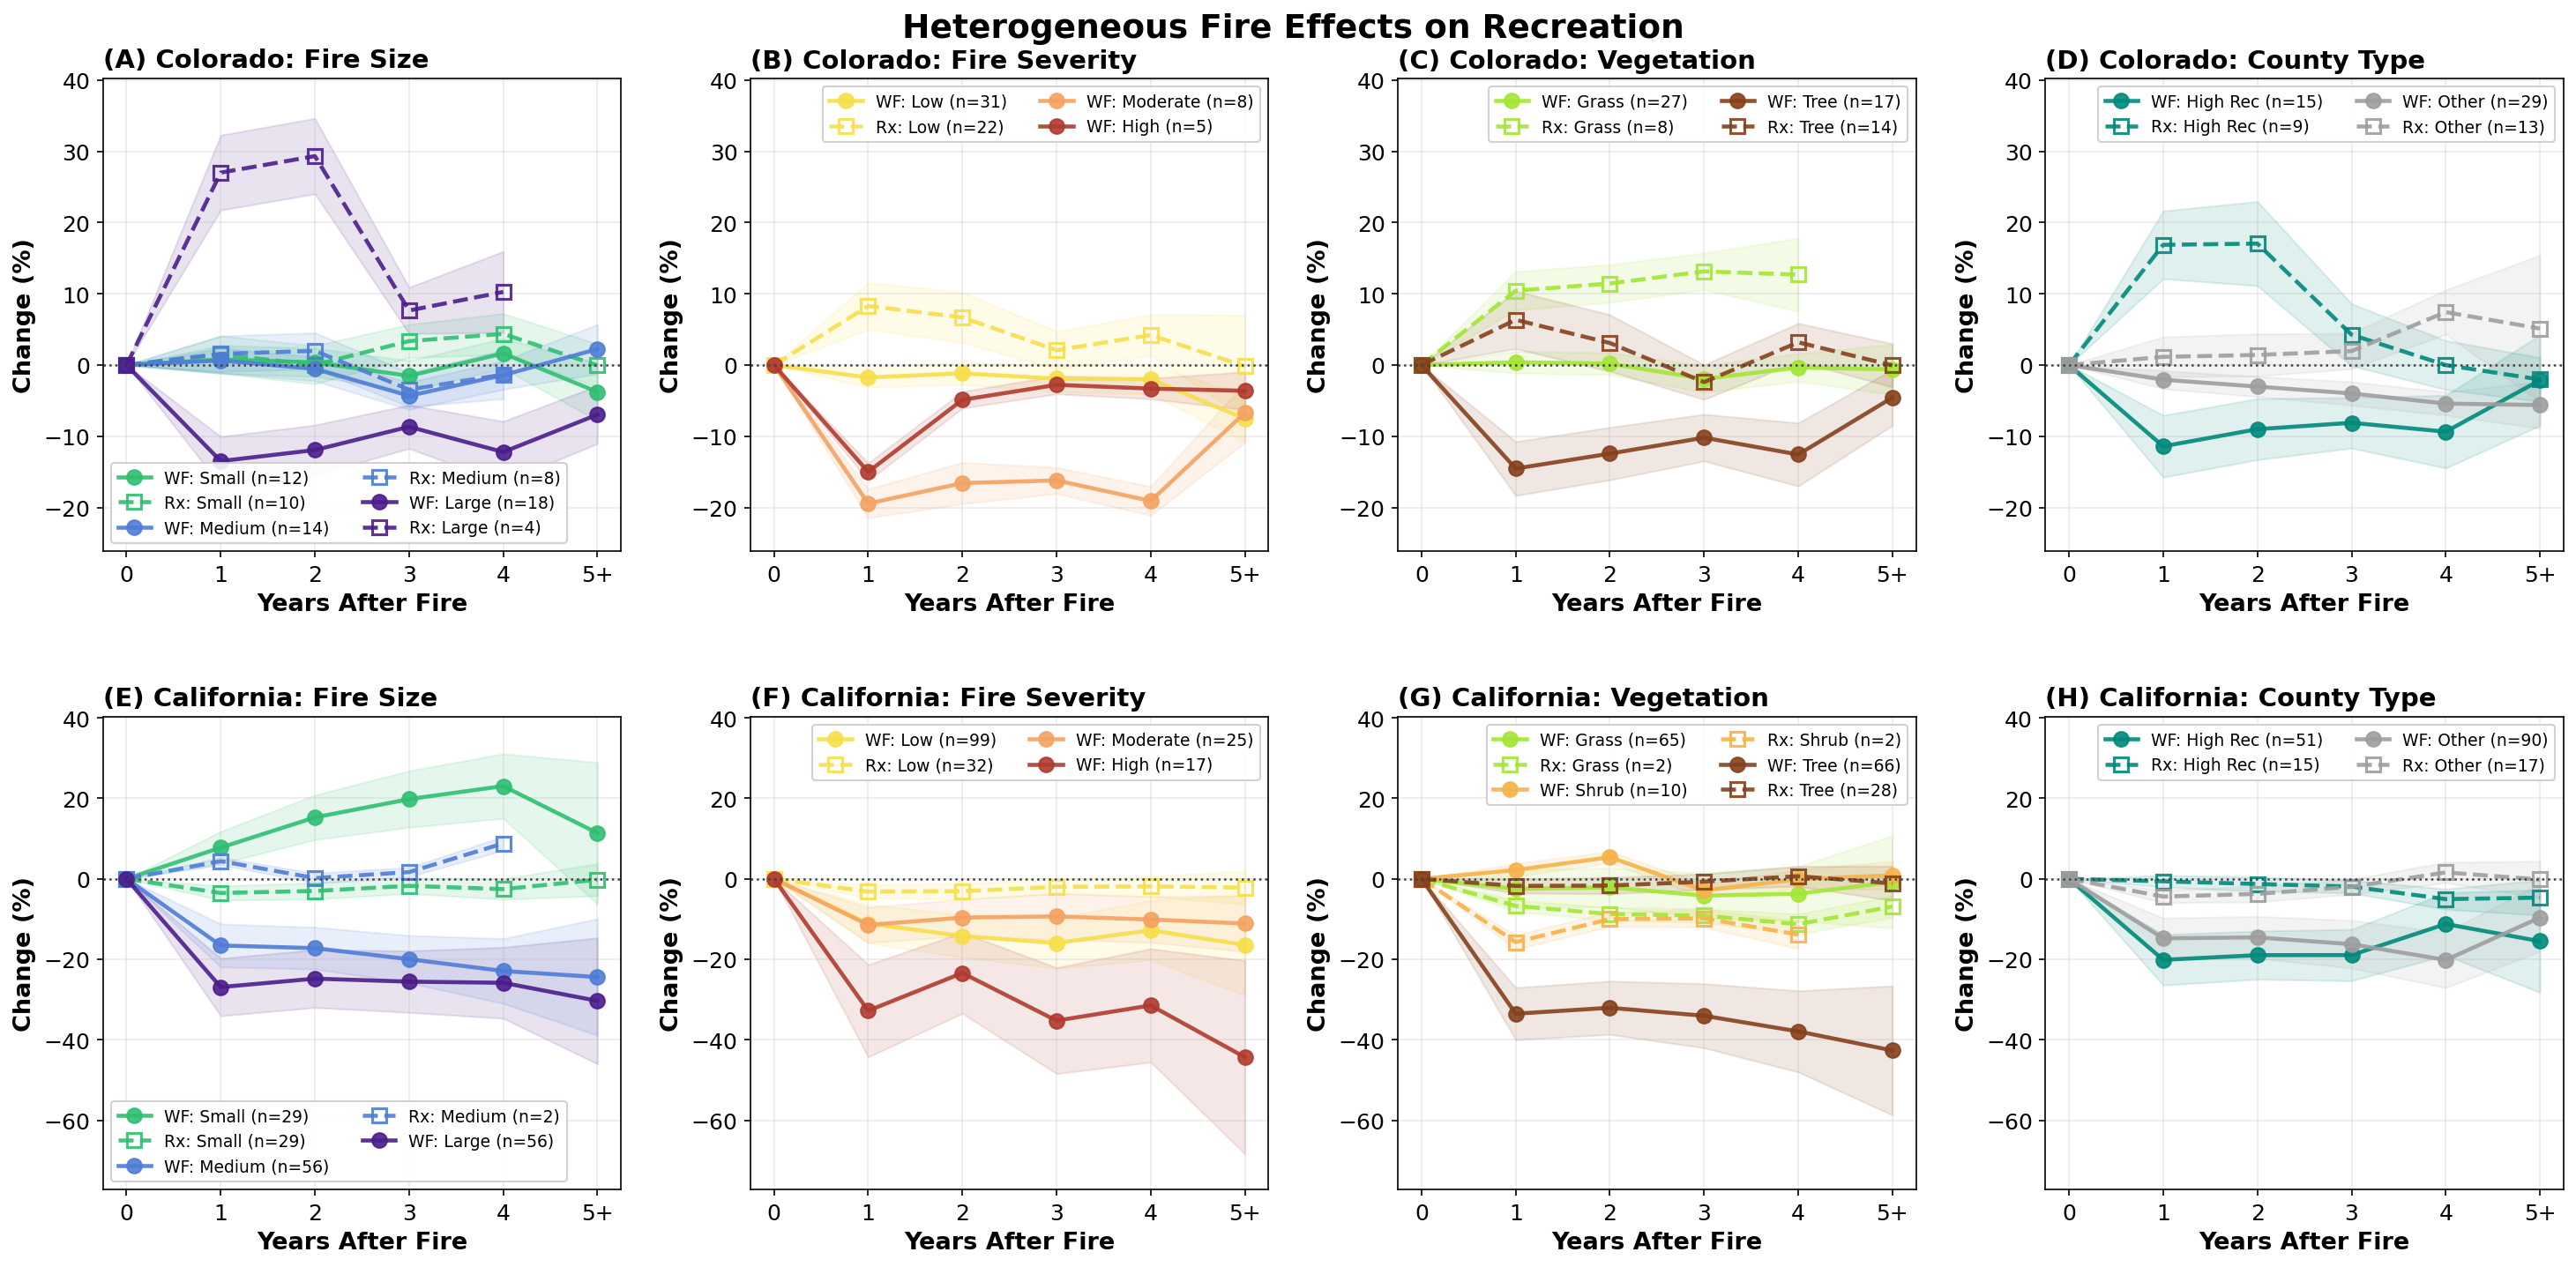


DONE


In [3]:
"""
Plot Heterogeneous Fire Effects
================================
Loads DiD results and creates publication-ready figures.

Displays in notebook and saves to files.
"""

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os
import warnings
from pathlib import Path
import logging

# Suppress any warnings
warnings.filterwarnings('ignore')
logging.getLogger('fontTools').setLevel(logging.WARNING)
logging.getLogger('fontTools.subset').setLevel(logging.WARNING)

# ============================================================
# SETTINGS
# ============================================================

# Resolve directory of this file (works in .py; falls back to CWD in notebooks)
try:
    HERE = Path(__file__).resolve().parent
except NameError:
    HERE = Path.cwd()

# Where to load results from (relative to this notebook/script)
RESULTS_CSV = (HERE / "../outputs/dif_in_dif/did_heterogeneity_results.csv").resolve()

# Where to save figures (relative to this notebook/script)
OUTPUT_DIR = (HERE / "../outputs/figures").resolve()

# ============================================================
# FIGURE SETTINGS
# ============================================================

plt.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.dpi": 600,
    "figure.dpi": 150,
    "font.size": 14,
    "font.family": "sans-serif",
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11,
})

# Colorblind-friendly colors
size_colors = {
    'small': '#2FBF71',   # Green
    'medium': '#4F7CD6',  # Blue
    'large': '#4B1D8B',   # Purple
}

sev_colors = {
    'low': '#F7DF4A',      # Yellow
    'moderate': '#F4A261', # Orange
    'high': '#B03A2E',     # Red
}

veg_colors = {
    'grass': '#A3E635',  # Lime green
    'shrub': '#F7B24A',  # Tan
    'tree': '#85411C',   # Brown
}

rec_colors = {
    'high_recreation': '#00897B',  # Teal
    'non_recreation': '#9E9E9E',   # Gray
}

# ============================================================
# LOAD DATA
# ============================================================

print("=" * 60)
print("LOADING RESULTS")
print("=" * 60)

df = pd.read_csv(RESULTS_CSV)
print(f"\n✓ Loaded {len(df)} rows from {RESULTS_CSV}")
print(f"\nStates: {df['state'].unique()}")
print(f"Fire types: {df['fire_type'].unique()}")
print(f"Stratifications: {df['stratification'].unique()}")

# ============================================================
# CREATE FIGURE (NOW 2x4 GRID)
# ============================================================

print("\n" + "=" * 60)
print("CREATING FIGURE: HETEROGENEOUS EFFECTS")
print("=" * 60)

fig = plt.figure(figsize=(20, 10))
gs = gridspec.GridSpec(2, 4, figure=fig, hspace=0.35, wspace=0.25,
                       left=0.05, right=0.98, top=0.92, bottom=0.08)

def plot_panel(ax, state, stratification, category_colors, categories):
    """Plot one panel of the figure"""
    
    # Filter data
    panel_data = df[(df['state'] == state) & 
                    (df['stratification'] == stratification)]
    
    if len(panel_data) == 0:
        ax.text(0.5, 0.5, 'No data available', 
                ha='center', va='center', transform=ax.transAxes)
        return
    
    # Plot each category × fire type combination
    for category in categories:
        for ft in ['wildfire', 'prescribed']:
            
            data = panel_data[(panel_data['stratum'] == category) & 
                             (panel_data['fire_type'] == ft)]
            
            if len(data) == 0:
                continue
            
            # Sort by year
            data = data.sort_values('year')
            
            years = data['year'].values
            effects = data['effect_pct'].values
            ci_lower = data['ci_lower'].values
            ci_upper = data['ci_upper'].values
            n_treated = data['n_treated'].iloc[0] if len(data) > 0 else 0
            
            # Styling
            color = category_colors[category]
            linestyle = '-' if ft == 'wildfire' else '--'
            marker = 'o' if ft == 'wildfire' else 's'
            fillstyle = 'full' if ft == 'wildfire' else 'none'
            markeredgewidth = 1.5 if ft == 'prescribed' else 1.0
            
            ft_abbr = 'WF' if ft == 'wildfire' else 'Rx'
            
            # Better labels for recreation
            if stratification == 'recreation':
                cat_label = 'High Rec' if category == 'high_recreation' else 'Other'
            else:
                cat_label = category.capitalize()
            
            label = f"{ft_abbr}: {cat_label} (n={n_treated})"
            
            # Plot
            ax.plot(years, effects, marker=marker, markersize=8, linewidth=2.2,
                    linestyle=linestyle, color=color, label=label, alpha=0.9,
                    fillstyle=fillstyle, markeredgewidth=markeredgewidth, 
                    markeredgecolor=color)
            ax.fill_between(years, ci_lower, ci_upper, alpha=0.12, color=color)
    
    # Formatting
    ax.axhline(0, color='#424242', linestyle=':', linewidth=1.2)
    ax.set_xlabel('Years After Fire', fontsize=13, fontweight='bold')
    ax.set_ylabel('Change (%)', fontsize=13, fontweight='bold')
    ax.set_xticks(range(6))
    ax.set_xticklabels(['0', '1', '2', '3', '4', '5+'], fontsize=12)
    ax.tick_params(axis='y', labelsize=12)
    ax.grid(alpha=0.25)
    ax.legend(loc='best', fontsize=9, ncol=2, framealpha=0.9)

# Row 1: Colorado
ax_co_size = fig.add_subplot(gs[0, 0])
plot_panel(ax_co_size, 'CO', 'size', size_colors, ['small', 'medium', 'large'])
ax_co_size.set_title('(A) Colorado: Fire Size', loc='left', fontsize=14, fontweight='bold')

ax_co_sev = fig.add_subplot(gs[0, 1])
plot_panel(ax_co_sev, 'CO', 'severity', sev_colors, ['low', 'moderate', 'high'])
ax_co_sev.set_title('(B) Colorado: Fire Severity', loc='left', fontsize=14, fontweight='bold')

ax_co_veg = fig.add_subplot(gs[0, 2])
plot_panel(ax_co_veg, 'CO', 'vegetation', veg_colors, ['grass', 'tree'])
ax_co_veg.set_title('(C) Colorado: Vegetation', loc='left', fontsize=14, fontweight='bold')

ax_co_rec = fig.add_subplot(gs[0, 3])
plot_panel(ax_co_rec, 'CO', 'recreation', rec_colors, ['high_recreation', 'non_recreation'])
ax_co_rec.set_title('(D) Colorado: County Type', loc='left', fontsize=14, fontweight='bold')

# Row 2: California
ax_ca_size = fig.add_subplot(gs[1, 0])
plot_panel(ax_ca_size, 'CA', 'size', size_colors, ['small', 'medium', 'large'])
ax_ca_size.set_title('(E) California: Fire Size', loc='left', fontsize=14, fontweight='bold')

ax_ca_sev = fig.add_subplot(gs[1, 1])
plot_panel(ax_ca_sev, 'CA', 'severity', sev_colors, ['low', 'moderate', 'high'])
ax_ca_sev.set_title('(F) California: Fire Severity', loc='left', fontsize=14, fontweight='bold')

ax_ca_veg = fig.add_subplot(gs[1, 2])
plot_panel(ax_ca_veg, 'CA', 'vegetation', veg_colors, ['grass', 'shrub', 'tree'])
ax_ca_veg.set_title('(G) California: Vegetation', loc='left', fontsize=14, fontweight='bold')

ax_ca_rec = fig.add_subplot(gs[1, 3])
plot_panel(ax_ca_rec, 'CA', 'recreation', rec_colors, ['high_recreation', 'non_recreation'])
ax_ca_rec.set_title('(H) California: County Type', loc='left', fontsize=14, fontweight='bold')

# Sync y-limits within rows
def sync_ylims(axes_list):
    """Make all axes in list have same y-limits"""
    all_lims = []
    for ax in axes_list:
        lims = ax.get_ylim()
        all_lims.extend(lims)
    
    if all_lims:
        ymin, ymax = min(all_lims), max(all_lims)
        span = ymax - ymin
        pad = 0.05 * span if span > 0 else 1
        for ax in axes_list:
            ax.set_ylim(ymin - pad, ymax + pad)

# Sync Colorado panels
sync_ylims([ax_co_size, ax_co_sev, ax_co_veg, ax_co_rec])

# Sync California panels
sync_ylims([ax_ca_size, ax_ca_sev, ax_ca_veg, ax_ca_rec])

# Title
fig.suptitle('Heterogeneous Fire Effects on Recreation', 
             fontsize=18, fontweight='bold', y=0.97)

# Save high-resolution figures
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Standard publication quality (600 DPI)
fig.savefig(OUTPUT_DIR / 'Heterogeneous_Effects.png', 
            bbox_inches='tight', dpi=600)

print("\n✓ Saved figures to:", OUTPUT_DIR)
print("  • Heterogeneous_Effects.png (600 DPI)")

# Display in notebook
plt.show()

print("\n" + "=" * 60)
print("DONE")
print("=" * 60)